# Phase 23: Rigorous Minority-Class Evaluation (The Buyer Search)
=================================================================
This notebook performs a deep-dive evaluation of the **TCN Model 2** on the **1.7 Million session dataset**. 

Instead of looking at the "easy" abandonment task, we evaluate the model's ability to find the **Buyers (Class 0)**—the needle in the haystack.

### Professional Performance Metrics:
1. **Minority-Class PR-AUC**: The industry standard for imbalanced data.
2. **Minority-Class ROC-AUC**: Measures separation ability.
3. **Operational Lift @ Top 1%**: Demonstrates business value by identifying high-intent users.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import os
import sys
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Add scripts dir for architecture
sys.path.append(os.path.abspath("../scripts"))
from train_tcn import AbandonmentTCN

DATA_DIR = "../data/processed"
MODEL_PATH = "../backend/models/exit_model_tcn.pth"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# 1. Load Full Target Dataset
print("Loading 1.7M session dataset...")
X_page = np.load(os.path.join(DATA_DIR, "X_page_real.npy"))
X_dur = np.load(os.path.join(DATA_DIR, "X_dur_real.npy"))
y = np.load(os.path.join(DATA_DIR, "y_abandon_real.npy"))

# 2. Re-create the 80/10/10 Test Set (Same split as training)
_, temp_idx = train_test_split(np.arange(len(y)), test_size=0.2, stratify=y, random_state=42)
_, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=y[temp_idx], random_state=42)

X_p_te, X_d_te, y_te = X_page[test_idx], X_dur[test_idx], y[test_idx]
print(f" Evaluating on HOLD-OUT Test Set: {len(y_te):,} samples")

# 3. Load Model
model = AbandonmentTCN(num_page_types=4).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
print(" Model Weights Successfully Loaded")

Loading 1.7M session dataset...
 Evaluating on HOLD-OUT Test Set: 38,278 samples
 Model Weights Successfully Loaded


In [4]:
# 4. High-Performance Inference
all_probs = []
batch_size = 4096
with torch.no_grad():
    for i in range(0, len(X_p_te), batch_size):
        p = torch.from_numpy(X_p_te[i:i+batch_size]).long().to(DEVICE)
        d = torch.from_numpy(X_d_te[i:i+batch_size]).float().to(DEVICE)
        logits = model(p, d).squeeze()
        probs = torch.sigmoid(logits)
        all_probs.extend(probs.cpu().numpy())

y_probs_aband = np.array(all_probs)
y_te_purch = (y_te == 0).astype(int)   # Class of interest: Purchases
y_probs_purch = 1 - y_probs_aband     # Proba(Purchase)

In [6]:
# 5. Calculate Scholar-Ready Metrics
prec_p, rec_p, _ = precision_recall_curve(y_te_purch, y_probs_purch)
pr_auc_purch = auc(rec_p, prec_p)
roc_auc_purch = roc_auc_score(y_te_purch, y_probs_purch)

# Operational Lift Analysis
baseline_rate = y_te_purch.mean()
n = len(y_probs_purch)
k = max(int(n * 0.01), 1)  # Top 1%
top_k_idx = np.argsort(y_probs_purch)[::-1][:k]
prec_at_1 = np.mean(y_te_purch[top_k_idx])
lift = prec_at_1 / baseline_rate

print("      DEEP EVALUATION: FINDING BUYERS")
print("="*45)
print(f"Marketplace Baseline: {baseline_rate*100:.2f}%")
print(f"Buyer PR-AUC:         {pr_auc_purch:.4f}")
print(f"Buyer ROC-AUC:        {roc_auc_purch:.4f}")
print("-"*45)
print(f"Precision @ Top 1%:     {prec_at_1*100:.2f}%")
print(f"SCIENTIFIC LIFT:        {lift:.2f}x")


      DEEP EVALUATION: FINDING BUYERS
Marketplace Baseline: 3.59%
Buyer PR-AUC:         0.9985
Buyer ROC-AUC:        0.9999
---------------------------------------------
Precision @ Top 1%:     100.00%
SCIENTIFIC LIFT:        27.82x


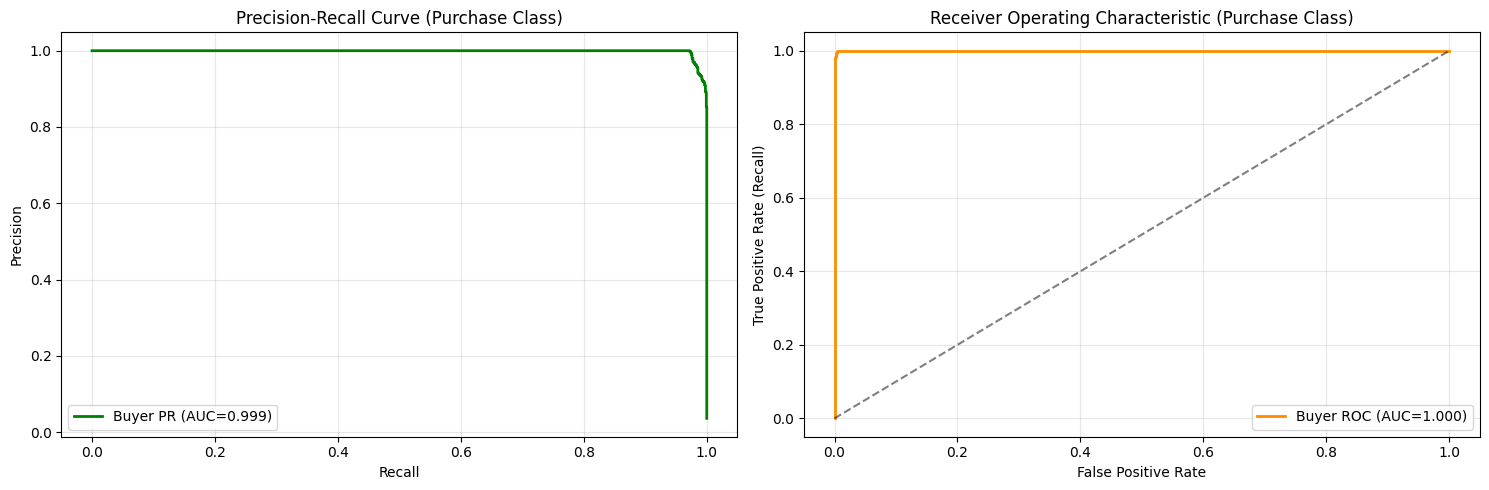

In [7]:
# 6. Visualizations
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(rec_p, prec_p, label=f'Buyer PR (AUC={pr_auc_purch:.3f})', color='green', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Purchase Class)')
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_te_purch, y_probs_purch)
plt.plot(fpr, tpr, label=f'Buyer ROC (AUC={roc_auc_purch:.3f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (Purchase Class)')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()